In [7]:
# Water Flow Blockage Detection using YOLOv8
# Modified from Accident Detection Template
# LOCAL VERSION

# 1. SETUP ENVIRONMENT
# ============================================
print("🔧 Setting up environment for Water Flow Blockage Detection...")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import shutil
import random
from sklearn.model_selection import train_test_split
import yaml
from pathlib import Path

# Set matplotlib to display in-line if using Jupyter locally
# %matplotlib inline  # Uncomment if using Jupyter Notebook



🔧 Setting up environment for Water Flow Blockage Detection...


In [8]:
# 2. DATASET SETUP
# ============================================
print("📂 Setting up dataset structure...")

# Local dataset path - UPDATE THIS TO YOUR ACTUAL PATH
DATASET_PATH = r"D:\Bhargav\Bhargav\b&uB"

# Verify the dataset path exists
if not os.path.exists(DATASET_PATH):
    print(f"❌ Error: Dataset path not found: {DATASET_PATH}")
    print("Please update DATASET_PATH to the correct location.")
    exit()

# Create YOLO dataset structure
def create_yolo_structure(base_path, dataset_path):
    """Create YOLO dataset structure from the b&uB folder"""
    
    # Define class names
    classes = ["blocked", "unblocked", "other"]
    
    # Create directory structure
    yolo_dir = os.path.join(base_path, "yolo_dataset")
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(yolo_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(yolo_dir, split, 'labels'), exist_ok=True)
    
    # Collect all images
    all_images = []
    image_labels = []
    
    # Map folder names to class indices
    folder_to_class = {
        'Blocked Images': 0,  # blocked
        'Unblocked Images': 1,  # unblocked
        'Other images': 2  # other
    }
    
    # Scan all folders
    for folder_name, class_idx in folder_to_class.items():
        folder_path = os.path.join(dataset_path, folder_name)
        if os.path.exists(folder_path):
            print(f"📁 Processing {folder_name} -> class {class_idx}")
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_name in images:
                img_path = os.path.join(folder_path, img_name)
                all_images.append(img_path)
                image_labels.append((img_path, class_idx))
        else:
            print(f"⚠️ Warning: Folder not found: {folder_path}")
    
    print(f"📊 Total images found: {len(all_images)}")
    
    # Split dataset
    train_val, test = train_test_split(image_labels, test_size=0.15, random_state=42)
    train, val = train_test_split(train_val, test_size=0.15, random_state=42)
    
    # Helper function to copy images and create label files
    def process_split(split_data, split_name):
        print(f"📝 Creating {split_name} set...")
        
        # Create split directory
        split_img_dir = os.path.join(yolo_dir, split_name, 'images')
        split_label_dir = os.path.join(yolo_dir, split_name, 'labels')
        
        for img_path, class_idx in split_data:
            # Copy image
            img_name = os.path.basename(img_path)
            dst_img_path = os.path.join(split_img_dir, img_name)
            shutil.copy2(img_path, dst_img_path)
            
            # Create label file (for classification, we'll use bounding boxes covering entire image)
            label_name = os.path.splitext(img_name)[0] + '.txt'
            label_path = os.path.join(split_label_dir, label_name)
            
            # For classification, create a bounding box covering the entire image
            # We'll assume image dimensions and create normalized coordinates
            try:
                img = cv2.imread(dst_img_path)
                if img is not None:
                    h, w = img.shape[:2]
                    # Create a bounding box covering 90% of the image centered
                    x_center = 0.5
                    y_center = 0.5
                    box_width = 0.9
                    box_height = 0.9
                    
                    with open(label_path, 'w') as f:
                        f.write(f"{class_idx} {x_center} {y_center} {box_width} {box_height}\n")
                else:
                    print(f"⚠️ Could not read image: {img_path}")
            except Exception as e:
                print(f"⚠️ Error processing {img_path}: {e}")
    
    # Process all splits
    process_split(train, 'train')
    process_split(val, 'val')
    process_split(test, 'test')
    
    # Create dataset.yaml file
    yaml_content = f"""
# Water Flow Blockage Dataset
path: {os.path.abspath(yolo_dir)}  # dataset root dir
train: train/images  # train images (relative to 'path')
val: val/images      # val images (relative to 'path')
test: test/images    # test images (relative to 'path')

# Classes
names:
  0: blocked
  1: unblocked
  2: other

# Download script/API (optional)
# download: https://your-dataset-url.com
"""
    
    yaml_path = os.path.join(yolo_dir, 'dataset.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    print(f"✅ YOLO dataset created at: {yolo_dir}")
    print(f"📄 Dataset config: {yaml_path}")
    
    return yolo_dir, yaml_path

# Create YOLO dataset structure
yolo_dataset_dir, yaml_path = create_yolo_structure(DATASET_PATH, DATASET_PATH)


📂 Setting up dataset structure...
📁 Processing Blocked Images -> class 0
📁 Processing Unblocked Images -> class 1
📁 Processing Other images -> class 2
📊 Total images found: 6107
📝 Creating train set...
📝 Creating val set...
📝 Creating test set...
✅ YOLO dataset created at: D:\Bhargav\Bhargav\b&uB\yolo_dataset
📄 Dataset config: D:\Bhargav\Bhargav\b&uB\yolo_dataset\dataset.yaml


In [9]:
# 3. DATA EXPLORATION
# ============================================
print("🔍 Exploring dataset...")

def explore_dataset(yolo_dir):
    """Explore the created dataset"""
    
    splits = ['train', 'val', 'test']
    stats = {}
    
    for split in splits:
        img_dir = os.path.join(yolo_dir, split, 'images')
        label_dir = os.path.join(yolo_dir, split, 'labels')
        
        if os.path.exists(img_dir):
            images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
            
            stats[split] = {
                'images': len(images),
                'labels': len(labels)
            }
            
            # Count classes
            class_counts = {0: 0, 1: 0, 2: 0}
            for label_file in labels[:100]:  # Sample first 100
                label_path = os.path.join(label_dir, label_file)
                try:
                    with open(label_path, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if line.strip():
                                class_id = int(line.strip().split()[0])
                                if class_id in class_counts:
                                    class_counts[class_id] += 1
                except:
                    pass
            
            stats[split]['class_counts'] = class_counts
    
    # Print statistics
    print("\n📊 Dataset Statistics:")
    print("=" * 40)
    for split, data in stats.items():
        print(f"\n{split.upper()}:")
        print(f"  Images: {data['images']}")
        print(f"  Labels: {data['labels']}")
        if 'class_counts' in data:
            print("  Class Distribution:")
            for class_id, count in data['class_counts'].items():
                class_name = ["blocked", "unblocked", "other"][class_id]
                print(f"    {class_name}: {count}")
    
    return stats

# Explore the dataset
dataset_stats = explore_dataset(yolo_dataset_dir)


🔍 Exploring dataset...

📊 Dataset Statistics:

TRAIN:
  Images: 4370
  Labels: 4370
  Class Distribution:
    blocked: 1
    unblocked: 82
    other: 17

VAL:
  Images: 779
  Labels: 779
  Class Distribution:
    blocked: 3
    unblocked: 69
    other: 28

TEST:
  Images: 915
  Labels: 915
  Class Distribution:
    blocked: 1
    unblocked: 79
    other: 20



🖼️ Visualizing sample images...

TRAIN Samples:


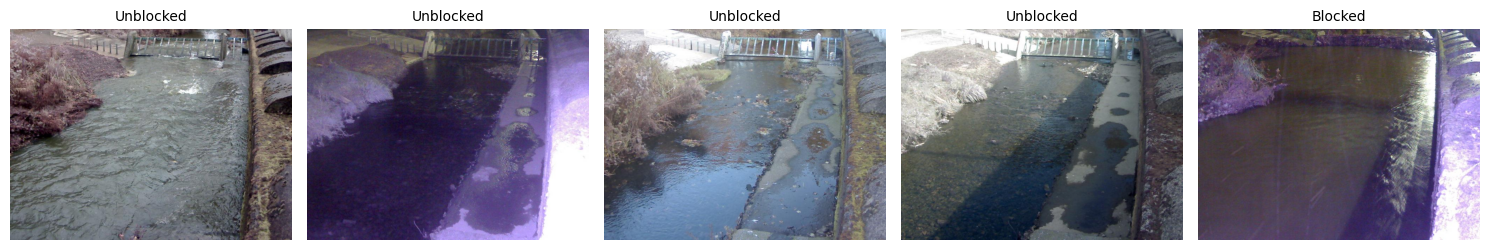


VAL Samples:


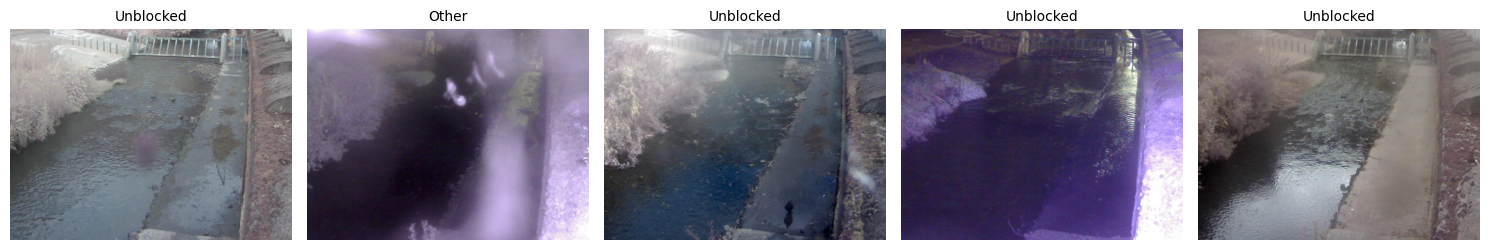

In [10]:


# 4. VISUALIZE SAMPLE IMAGES
# ============================================
print("\n🖼️ Visualizing sample images...")

def visualize_samples(yolo_dir, num_samples=5):
    """Visualize sample images with their labels"""
    
    splits = ['train', 'val']
    
    for split in splits:
        print(f"\n{split.upper()} Samples:")
        
        img_dir = os.path.join(yolo_dir, split, 'images')
        label_dir = os.path.join(yolo_dir, split, 'labels')
        
        if not os.path.exists(img_dir):
            continue
            
        images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not images:
            continue
            
        # Select random samples
        sample_images = random.sample(images, min(num_samples, len(images)))
        
        fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 3))
        if len(sample_images) == 1:
            axes = [axes]
        
        for idx, img_name in enumerate(sample_images):
            img_path = os.path.join(img_dir, img_name)
            label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')
            
            # Read image
            img = cv2.imread(img_path)
            if img is None:
                continue
                
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Read label
            class_id = -1
            if os.path.exists(label_path):
                try:
                    with open(label_path, 'r') as f:
                        lines = f.readlines()
                        if lines:
                            class_id = int(lines[0].strip().split()[0])
                except:
                    pass
            
            # Display image
            axes[idx].imshow(img_rgb)
            class_names = ["Blocked", "Unblocked", "Other"]
            title = f"{class_names[class_id] if 0 <= class_id < 3 else 'Unknown'}"
            axes[idx].set_title(title, fontsize=10)
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

# Visualize samples
visualize_samples(yolo_dataset_dir, num_samples=5)


In [11]:
# 5. MODEL TRAINING
# ============================================
print("\n🚀 Starting model training...")

def train_model(yaml_path, epochs=50, imgsz=640, batch=16):
    """Train YOLOv8 model"""
    
    # Load model (you can choose different versions: yolov8n.pt, yolov8s.pt, yolov8m.pt, yolov8l.pt, yolov8x.pt)
    model = YOLO('yolov8n.pt')  # Using nano version for faster training
    
    # Train the model with essential parameters only
    results = model.train(
        data=yaml_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        name='water_flow_blockage',
        save=True,
        save_period=10,
        pretrained=True,
        optimizer='AdamW',
        lr0=0.001,
        augment=True,
        patience=20,
        device='cpu',  # Change to 'cuda' if you have GPU
        workers=4,
        seed=42,
        val=True,
        plots=True,
        box=7.5,
        cls=0.5,
        dfl=1.5,
        amp=True,
        fraction=1.0,
        cache=False,
        conf=0.001,
        iou=0.7,
        max_det=300,
        half=False,
        dnn=False,
        vid_stride=1,
        visualize=False,
        agnostic_nms=False,
        retina_masks=False,
        show=False,
        save_frames=False,
        save_txt=False,
        save_conf=False,
        save_crop=False,
        show_labels=True,
        show_conf=True,
        show_boxes=True,
    )
    
    return results, model

# Train the model
try:
    print(f"📋 Training configuration:")
    print(f"  Dataset: {yaml_path}")
    print(f"  Model: yolov8n.pt")
    print(f"  Device: cpu")  # Change to 'cuda' if you have GPU
    
    # You can adjust these parameters based on your system capabilities
    training_results, trained_model = train_model(
        yaml_path=yaml_path,
        epochs=10,      # Reduced for local training
        imgsz=640,      # Image size
        batch=8         # Reduced batch size for local training
    )
    
    print("✅ Training completed!")
    
except Exception as e:
    print(f"❌ Training error: {e}")
    print("Trying with simpler configuration...")
    
    # Fallback to simpler training
    try:
        model = YOLO('yolov8n.pt')
        training_results = model.train(
            data=yaml_path,
            epochs=30,
            imgsz=320,
            batch=4,
            device='cpu'
        )
        print("✅ Training completed with fallback configuration!")
    except Exception as e2:
        print(f"❌ Fallback training also failed: {e2}")


🚀 Starting model training...
📋 Training configuration:
  Dataset: D:\Bhargav\Bhargav\b&uB\yolo_dataset\dataset.yaml
  Model: yolov8n.pt
  Device: cpu
New https://pypi.org/project/ultralytics/8.3.237 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.13.1 torch-2.9.1+cpu CPU (12th Gen Intel Core i5-1240P)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.001, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Bhargav\Bhargav\b&uB\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=

In [14]:
# 6. MODEL EVALUATION
# ============================================
print("\n📊 Evaluating model...")

def evaluate_model(model_path, yaml_path):
    """Evaluate trained model"""
    
    # Load best model
    best_model_path = os.path.join('runs', 'detect', 'water_flow_blockage2', 'weights', 'best.pt')
    
    if os.path.exists(best_model_path):
        model = YOLO(best_model_path)
        
        # Validate
        metrics = model.val(
            data=yaml_path,
            imgsz=640,
            batch=8,
            conf=0.25,
            iou=0.45,
            device='cpu',
            split='val'
        )
        
        print("\n📈 Validation Results:")
        print(f"  mAP50: {metrics.box.map50:.4f}")
        print(f"  mAP50-95: {metrics.box.map:.4f}")
        print(f"  Precision: {metrics.box.mp:.4f}")
        print(f"  Recall: {metrics.box.mr:.4f}")
        
        return metrics
    else:
        print("❌ Best model not found!")
        return None

# Evaluate if training was successful
try:
    evaluation_metrics = evaluate_model(yolo_dataset_dir, yaml_path)
except Exception as e:
    print(f"❌ Evaluation error: {e}")



📊 Evaluating model...
Ultralytics 8.3.235  Python-3.13.1 torch-2.9.1+cpu CPU (12th Gen Intel Core i5-1240P)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 565.9231.4 MB/s, size: 60.7 KB)
val: Scanning D:\Bhargav\Bhargav\b&uB\yolo_dataset\val\labels.cache... 779 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 779/779 877.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 98/98 1.5it/s 1:060.7sss
                   all        779        779      0.961       0.81      0.889      0.889
               blocked         18         18      0.937        0.5      0.704      0.704
             unblocked        609        609      0.965      0.995      0.987      0.987
                 other        152        152      0.979      0.935      0.975      0.975
Speed: 1.5ms preprocess, 75.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results 


🔮 Running inference on test images...
📷 Found 915 test images

image 1/1 D:\Bhargav\Bhargav\b&uB\yolo_dataset\test\images\01_02_25,20_23_21.jpg: 480x640 1 unblocked, 79.3ms
Speed: 4.2ms preprocess, 79.3ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)
  ✅ Processed: 01_02_25,20_23_21.jpg


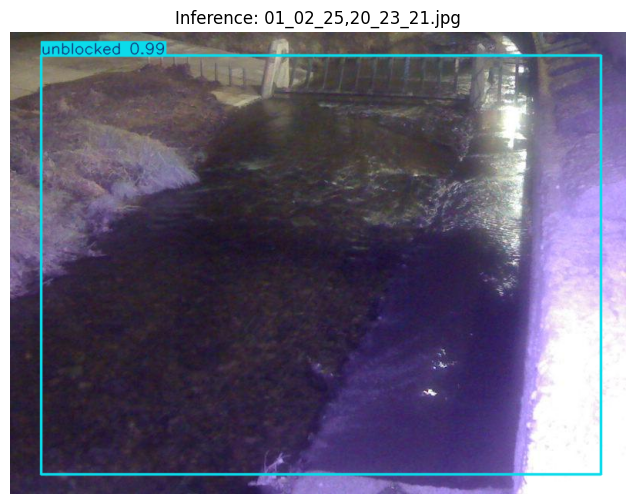


image 1/1 D:\Bhargav\Bhargav\b&uB\yolo_dataset\test\images\01_04_25,04_12_22.jpg: 480x640 1 unblocked, 60.6ms
Speed: 3.0ms preprocess, 60.6ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
  ✅ Processed: 01_04_25,04_12_22.jpg

image 1/1 D:\Bhargav\Bhargav\b&uB\yolo_dataset\test\images\01_04_25,09_12-23.jpg: 480x640 1 unblocked, 50.8ms
Speed: 1.6ms preprocess, 50.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
  ✅ Processed: 01_04_25,09_12-23.jpg

image 1/1 D:\Bhargav\Bhargav\b&uB\yolo_dataset\test\images\01_04_25,12_12-2.jpg: 480x640 1 unblocked, 54.8ms
Speed: 1.6ms preprocess, 54.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
  ✅ Processed: 01_04_25,12_12-2.jpg

image 1/1 D:\Bhargav\Bhargav\b&uB\yolo_dataset\test\images\01_04_25,16_12_23.jpg: 480x640 1 unblocked, 59.8ms
Speed: 1.7ms preprocess, 59.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
  ✅ Processed: 01_04_25,16_12_23.jpg


In [21]:


# 7. INFERENCE ON TEST IMAGES
# ============================================
print("\n🔮 Running inference on test images...")

def run_inference(model_path, test_dir, output_dir='inference_results'):
    """Run inference on test images"""
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model
    if os.path.exists(model_path):
        model = YOLO(model_path)
    else:
        print(f"❌ Model not found: {model_path}")
        return
    
    # Get test images
    test_images_dir = os.path.join(test_dir, 'images')
    if not os.path.exists(test_images_dir):
        print(f"❌ Test directory not found: {test_images_dir}")
        return
    
    test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not test_images:
        print("❌ No test images found!")
        return
    
    print(f"📷 Found {len(test_images)} test images")
    
    # Process a few samples
    sample_images = test_images[:5]  # Process first 5 images
    
    for img_name in sample_images:
        img_path = os.path.join(test_images_dir, img_name)
        
        # Run inference
        results = model(img_path, conf=0.25)
        
        # Visualize results
        for r in results:
            # Plot with predictions
            im_array = r.plot()
            im = Image.fromarray(im_array[..., ::-1])
            
            # Save result
            output_path = os.path.join(output_dir, img_name)
            im.save(output_path)
            
            print(f"  ✅ Processed: {img_name}")
            
            # Display first image
            if img_name == sample_images[0]:
                plt.figure(figsize=(10, 6))
                plt.imshow(im)
                plt.title(f"Inference: {img_name}")
                plt.axis('off')
                plt.show()

# Run inference if model exists
best_model_path = os.path.join('runs', 'detect', 'water_flow_blockage2', 'weights', 'best.pt')
test_dir = os.path.join(yolo_dataset_dir, 'test')

if os.path.exists(best_model_path) and os.path.exists(test_dir):
    run_inference(best_model_path, test_dir)
else:
    print("⚠️ Skipping inference - model or test directory not available")


In [22]:

# 8. EXPORT MODEL (Optional)
# ============================================
print("\n📤 Exporting model (optional)...")

def export_model(model_path, export_dir='exported_models'):
    """Export model to different formats"""
    
    os.makedirs(export_dir, exist_ok=True)
    
    if os.path.exists(model_path):
        model = YOLO(model_path)
        
        # Export to ONNX
        onnx_path = os.path.join(export_dir, 'model.onnx')
        success = model.export(format='onnx', imgsz=640, simplify=True)
        
        if success:
            print(f"✅ Model exported to ONNX: {onnx_path}")
        else:
            print("❌ ONNX export failed")
        
        # Export to TensorRT (if GPU available)
        # try:
        #     trt_path = os.path.join(export_dir, 'model.engine')
        #     model.export(format='engine', imgsz=640)
        #     print(f"✅ Model exported to TensorRT")
        # except:
        #     print("⚠️ TensorRT export skipped (requires GPU)")
        
        return success
    else:
        print("❌ Model not found for export")
        return False

# Export if model exists
if os.path.exists(best_model_path):
    export_success = export_model(best_model_path)
else:
    print("⚠️ Skipping export - model not available")



📤 Exporting model (optional)...
Ultralytics 8.3.235  Python-3.13.1 torch-2.9.1+cpu CPU (12th Gen Intel Core i5-1240P)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs\detect\water_flow_blockage2\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   --- ------------------------------------ 1.3/16.5 MB 7.2 MB/s eta 0:00:03
   ------- -------------------------------- 3.1/16.5 MB 8.3 MB/s eta 0:00:02
   ------------ --------------------------- 5.2/16.5 MB 8.7 MB/s e

In [23]:

# 9. SUMMARY
# ============================================
print("\n" + "="*50)
print("🎯 WATER FLOW BLOCKAGE DETECTION - LOCAL SETUP")
print("="*50)
print(f"\n📁 Dataset Location: {DATASET_PATH}")
print(f"📊 Total Images Processed: {sum([s['images'] for s in dataset_stats.values()])}")
print(f"📦 YOLO Dataset Created: {yolo_dataset_dir}")

if os.path.exists(best_model_path):
    print(f"🤖 Model Trained: {best_model_path}")
    model_size = os.path.getsize(best_model_path) / (1024*1024)
    print(f"📏 Model Size: {model_size:.2f} MB")
else:
    print("🤖 Model: Not trained or training incomplete")

print("\n📋 Next Steps:")
print("  1. Review training results in 'runs/detect/water_flow_blockage/'")
print("  2. Adjust training parameters if needed")
print("  3. Test with new images using the trained model")
print("  4. Deploy model for real-time detection")

print("\n✅ Setup completed successfully!")


🎯 WATER FLOW BLOCKAGE DETECTION - LOCAL SETUP

📁 Dataset Location: D:\Bhargav\Bhargav\b&uB
📊 Total Images Processed: 6064
📦 YOLO Dataset Created: D:\Bhargav\Bhargav\b&uB\yolo_dataset
🤖 Model Trained: runs\detect\water_flow_blockage2\weights\best.pt
📏 Model Size: 5.94 MB

📋 Next Steps:
  1. Review training results in 'runs/detect/water_flow_blockage/'
  2. Adjust training parameters if needed
  3. Test with new images using the trained model
  4. Deploy model for real-time detection

✅ Setup completed successfully!
